# Nathan S Notebook
# Intro to Jupyter and Exploratory Data Analysis (EDA)

REQ: Open notebooks with a standard header including a good title, your company/name/alias, a link to the repo, purpose, and date.

REQ: For EDA projects, include dataset, description, and source information.

- Author: [Nathan S](https://github.com/nwn8/)
- Repository: [datafun-04-notebooks](https://github.com/nwn8/datafun-04-notebooks/)
- Purpose: Demonstrate a repeatable EDA workflow for a new, unexplored dataset
- Date: 2026-06

## Instructions

- Scan the headings first, to get an idea of the process and overall goal. 
- The provided content is a well-structured example that shows the process.
- Seek to understand the process and presentation of the work. 
- The goal is to be able to perform EDA **on any data you choose**. 

## Dataset Information

- Dataset: Seaborn Taxi Data
- Description: Size measurements for three penguin species (Adelie, Chinstrap, Gentoo) observed on three islands in the Palmer Archipelago, Antarctica.
- Source: [Seaborn Data Sets - Taxi](https://www.kaggle.com/datasets/abdoomoh/all-seaborn-built-in-datasets)
- Original Collection: Dr. Kristen Gorman and the Palmer Station Long Term Ecological Research (LTER) Program


This is a Markdown cell.

## Section 1. Project Setup and Imports



In [1]:
# This is a Python cell.


# === Section 1a. DECLARE IMPORTS (BRING IN FREE CODE) ===

import logging  # for type hinting only
from typing import Any, Final  # for type hinting

from datafun_toolkit.logger import get_logger, log_header
from matplotlib.axes import Axes
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Type hint for Axes object (basic plot type returned by Seaborn)
# A seaborn plot is a set of axes. Set title, labels, etc. on the axes.
# A figure can contain multiple axes (plots)
# from matplotlib.figure import Figure

# === Section 1b. CONFIGURE LOGGER ONCE PER NOTEBOOK ===

LOG: logging.Logger = get_logger("EDA-NB", level="DEBUG")
log_header(LOG, "EDA-NB")

# === Section 1c. Global Constants and Configuration ===

# CUSTOM: These are dataset-specific constants
# used in multiple places in the code.
# Inspect or explore the dataset to determine columns needed for analysis.

# CUSTOM: Data set name
DATASET_NAME: Final[str] = "taxis"

# CUSTOM: Grouping column (chose one categorical/non-numeric variable)
GROUP_COL: Final[str] = "color"

# CUSTOM: Numeric columns to analyze (chose 4-5 numeric variables)
SELECTED_NUMERIC_COLS: Final[list[str]] = [
      "passengers",
    "distance",
     "fare",
    "tip",
    "tolls",
    "total"
]

# === Section 1d. Pandas Configuration for Display ===

# Pandas display configuration (helps in notebooks)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

LOG.info("Imports complete.")

2026-06-05 11:05:53 | INFO | EDA-NB | === RUN START ===
2026-06-05 11:05:53 | INFO | EDA-NB | project=EDA-NB
2026-06-05 11:05:53 | INFO | EDA-NB | repo_dir=datafun-04-notebooks
2026-06-05 11:05:53 | INFO | EDA-NB | python=3.14.3
2026-06-05 11:05:53 | INFO | EDA-NB | os=Windows 11
2026-06-05 11:05:53 | INFO | EDA-NB | shell=powershell
2026-06-05 11:05:53 | INFO | EDA-NB | cwd=notebooks
2026-06-05 11:05:53 | INFO | EDA-NB | github_actions=False
2026-06-05 11:05:53 | INFO | EDA-NB | Imports complete.


## Section 2. Load the Data



In [2]:
# Python cell

# Load a dataset into a DataFrame.

# Seaborn provides clean built-in datasets for practice.
# Other projects may load from CSV, JSON, or a database.

# Load the penguins dataset from Seaborn
# Into a pandas DataFrame (2D table)
LOG.info(f"Loading dataset: {DATASET_NAME}")
df: pd.DataFrame = sns.load_dataset(DATASET_NAME)
LOG.info(f"Loaded: {df.shape[0]} rows, {df.shape[1]} columns")

2026-06-05 11:05:53 | INFO | EDA-NB | Loading dataset: taxis
2026-06-05 11:05:53 | INFO | EDA-NB | Loaded: 6433 rows, 14 columns


## Section 3. Inspect Data Shape and Structure



In [3]:
# Section 3 Python cell

# Preview the first few rows
# WHY: display() renders the DataFrame as a formatted table in the notebook.
#      A naked expression like df.head() only renders if it is the LAST line in a cell.
LOG.info("Previewing first few rows of the dataset")
display(df.head())

2026-06-05 11:05:53 | INFO | EDA-NB | Previewing first few rows of the dataset


,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan


In [4]:
# Section 3 Python cell

LOG.info("Column names")
print(list(df.columns))

2026-06-05 11:05:53 | INFO | EDA-NB | Column names


['pickup', 'dropoff', 'passengers', 'distance', 'fare', 'tip', 'tolls', 'total', 'color', 'payment', 'pickup_zone', 'dropoff_zone', 'pickup_borough', 'dropoff_borough']


In [5]:
# Section 3 Python cell

# DataFrame info (types and non-null counts)
# WHY: df.info() prints directly - no display() needed.
LOG.info("DataFrame info (types and non-null counts)")
df.info()

2026-06-05 11:05:53 | INFO | EDA-NB | DataFrame info (types and non-null counts)


<class 'pandas.DataFrame'>
RangeIndex: 6433 entries, 0 to 6432
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   pickup           6433 non-null   datetime64[us]
 1   dropoff          6433 non-null   datetime64[us]
 2   passengers       6433 non-null   int64         
 3   distance         6433 non-null   float64       
 4   fare             6433 non-null   float64       
 5   tip              6433 non-null   float64       
 6   tolls            6433 non-null   float64       
 7   total            6433 non-null   float64       
 8   color            6433 non-null   str           
 9   payment          6389 non-null   str           
 10  pickup_zone      6407 non-null   str           
 11  dropoff_zone     6388 non-null   str           
 12  pickup_borough   6407 non-null   str           
 13  dropoff_borough  6388 non-null   str           
dtypes: datetime64[us](2), float64(5), int64(1), str(6)


In [6]:
# Section 3 Python cell

# Get shape - number of rows and columns
# It has two parts so the return value is a tuple of (num_rows, num_columns)
shape: tuple[int, int] = df.shape

# To get each value, we can unpack the tuple into two variables
# This is a common Python idiom for working with tuples.
# Or we could just use shape[0] and shape[1] directly without unpacking.

num_rows, num_cols = shape

LOG.info(f"Dataset shape: {num_rows} rows, {num_cols} columns")

2026-06-05 11:05:53 | INFO | EDA-NB | Dataset shape: 6433 rows, 14 columns


## Section 4. Create Data Dictionary and Check Data Quality



In [7]:
# Section 4 Python cell

LOG.info("Building starter data dictionary")

data_dictionary = pd.DataFrame(
    {
        "column": df.columns,
        "dtype": [str(t) for t in df.dtypes],
        "missing_count": df.isna().sum().values,
        "missing_pct": (df.isna().mean() * 100).round(2).values,
    }
)

LOG.debug(f"\n{data_dictionary}")

2026-06-05 11:05:53 | INFO | EDA-NB | Building starter data dictionary
2026-06-05 11:05:53 | DEBUG | EDA-NB | 
             column           dtype  missing_count  missing_pct
0            pickup  datetime64[us]              0         0.00
1           dropoff  datetime64[us]              0         0.00
2        passengers           int64              0         0.00
3          distance         float64              0         0.00
4              fare         float64              0         0.00
5               tip         float64              0         0.00
6             tolls         float64              0         0.00
7             total         float64              0         0.00
8             color             str              0         0.00
9           payment             str             44         0.68
10      pickup_zone             str             26         0.40
11     dropoff_zone             str             45         0.70
12   pickup_borough             str             26       

In [8]:
# Section 4 Python cell

LOG.info("Missing values per column:")
LOG.info(df.isnull().sum())

LOG.info("Checking missing values per column")
LOG.debug(f"\n{df.isna().sum().sort_values(ascending=False)}")

dup_count = int(df.duplicated().sum())
LOG.info(f"Duplicate rows detected: {dup_count}")

LOG.info("Call describe() for numeric columns")
LOG.debug(f"\n{df[SELECTED_NUMERIC_COLS].describe()}\n")

2026-06-05 11:05:53 | INFO | EDA-NB | Missing values per column:
2026-06-05 11:05:53 | INFO | EDA-NB | pickup              0
dropoff             0
passengers          0
distance            0
fare                0
tip                 0
tolls               0
total               0
color               0
payment            44
pickup_zone        26
dropoff_zone       45
pickup_borough     26
dropoff_borough    45
dtype: int64
2026-06-05 11:05:53 | INFO | EDA-NB | Checking missing values per column
2026-06-05 11:05:53 | DEBUG | EDA-NB | 
dropoff_zone       45
dropoff_borough    45
payment            44
pickup_zone        26
pickup_borough     26
pickup              0
tip                 0
fare                0
distance            0
passengers          0
dropoff             0
color               0
tolls               0
total               0
dtype: int64
2026-06-05 11:05:53 | INFO | EDA-NB | Duplicate rows detected: 0
2026-06-05 11:05:53 | INFO | EDA-NB | Call describe() for numeric columns
202

## Section 5. Create Clean View for EDA


In [9]:
# Section 5 Python cell

# Build the list of columns we require to be non-missing
# This includes all the selected numeric columns plus the grouping column.
# SELECTED_NUMERIC_COLS is a list of strings,
# GROUP_COL is a single string
# Wrap GROUP_COL in a list - two lists can be combined with +
cols_required: list[str] = SELECTED_NUMERIC_COLS + [GROUP_COL]
LOG.debug(f"Columns required to be non-missing: {cols_required}")

# Drop a row if it is missing a value in ANY of the required columns
# dropna(subset=...) only looks at the specified columns, not the whole row
# .copy() creates a new DataFrame so we don't accidentally modify the original
df_clean: pd.DataFrame = df.dropna(subset=cols_required).copy()

# Compare sizes
count_original: int = df.shape[0]
count_clean: int = df_clean.shape[0]
count_dropped: int = count_original - count_clean

print(f"Original rows: {count_original}")
print(f"Clean rows:    {count_clean}")
print(f"Rows dropped:  {count_dropped}")

LOG.info(f"Original rows: {count_original}")
LOG.info(f"Clean rows:    {count_clean}")
LOG.info(f"Rows dropped:  {count_dropped}")

2026-06-05 11:05:53 | DEBUG | EDA-NB | Columns required to be non-missing: ['passengers', 'distance', 'fare', 'tip', 'tolls', 'total', 'color']
2026-06-05 11:05:53 | INFO | EDA-NB | Original rows: 6433
2026-06-05 11:05:53 | INFO | EDA-NB | Clean rows:    6433
2026-06-05 11:05:53 | INFO | EDA-NB | Rows dropped:  0


Original rows: 6433
Clean rows:    6433
Rows dropped:  0


## Section 6. Descriptive Statistics for Numeric Columns


In [10]:
# Section 6 Python cell

LOG.info("--------------- Manual statistics ---------------")

# Example: Calculate statistics for a specific column with numpy
mean_distance = np.mean(df_clean["distance"])
std_distance = np.std(df_clean["distance"])
min_distance = np.min(df_clean["distance"])
max_distance = np.max(df_clean["distance"])
range_distance = np.ptp(df_clean["distance"])  # peak to peak (max - min)

# Log the example results with formatting
LOG.debug("Distance Statistics (using numpy):")
LOG.debug(f"  Mean: {mean_distance:.2f} g")
LOG.debug(f"  Std Dev: {std_distance:.2f} g")
LOG.debug(f"  Min: {min_distance:.2f} g")
LOG.debug(f"  Max: {max_distance:.2f} g")
LOG.debug(f"  Range: {range_distance:.2f} g")

2026-06-05 11:05:53 | INFO | EDA-NB | --------------- Manual statistics ---------------
2026-06-05 11:05:53 | DEBUG | EDA-NB | Distance Statistics (using numpy):
2026-06-05 11:05:53 | DEBUG | EDA-NB |   Mean: 3.02 g
2026-06-05 11:05:53 | DEBUG | EDA-NB |   Std Dev: 3.83 g
2026-06-05 11:05:53 | DEBUG | EDA-NB |   Min: 0.00 g
2026-06-05 11:05:53 | DEBUG | EDA-NB |   Max: 36.70 g
2026-06-05 11:05:53 | DEBUG | EDA-NB |   Range: 36.70 g


In [11]:
# Section 6 Python cell

# LOG.info("--------------- Using pandas describe() method ---------------")

LOG.info("Computing overall descriptive statistics")

# Use describe() to get count, mean, std, min, 25%, 50%, 75%, max for numeric columns
# OPTION: Use .T to transpose the result so that columns become rows for easier reading in logs
stats_overall = df_clean[SELECTED_NUMERIC_COLS].describe().T
LOG.debug(f"\n{stats_overall}")

LOG.info("--------------- Using pandas groupby() and agg() ---------------")

LOG.info("Computing descriptive statistics by group")

# Step 1: Select only the numeric columns we want to summarize
df_numeric_subset: pd.DataFrame = df_clean[SELECTED_NUMERIC_COLS]

# Step 2: Split the numeric subset into groups based on the grouping column
# groupby() returns a GroupBy object - not a DataFrame yet, just a plan to group
grouped = df_numeric_subset.groupby(df_clean[GROUP_COL])

# Step 3: For each group, compute multiple summary statistics at once
# agg() applies each function in the list to each numeric column
# The result has a multi-level column index: (numeric_column, statistic)
df_stats_by_group: pd.DataFrame = grouped.agg(["count", "mean", "std", "min", "max"])

LOG.debug(f"\n{df_stats_by_group}")

2026-06-05 11:05:53 | INFO | EDA-NB | Computing overall descriptive statistics
2026-06-05 11:05:53 | DEBUG | EDA-NB | 
             count       mean        std  min    25%    50%    75%     max
passengers  6433.0   1.539251   1.203768  0.0   1.00   1.00   2.00    6.00
distance    6433.0   3.024617   3.827867  0.0   0.98   1.64   3.21   36.70
fare        6433.0  13.091073  11.551804  1.0   6.50   9.50  15.00  150.00
tip         6433.0   1.979220   2.448560  0.0   0.00   1.70   2.80   33.20
tolls       6433.0   0.325273   1.415267  0.0   0.00   0.00   0.00   24.02
total       6433.0  18.517794  13.815570  1.3  10.80  14.16  20.30  174.82
2026-06-05 11:05:53 | INFO | EDA-NB | --------------- Using pandas groupby() and agg() ---------------
2026-06-05 11:05:53 | INFO | EDA-NB | Computing descriptive statistics by group
2026-06-05 11:05:53 | DEBUG | EDA-NB | 
       passengers                             distance                                  fare                        \
            cou

In [12]:
# Section 6 Python cell

LOG.info("--------------- Improving the output ---------------")

# Yuck: That's the multi-level column index in action.
# pandas lays out the result as (numeric_column, statistic) pairs
# side by side, wrapping when the terminal width runs out.
# With 4 numeric columns x 5 statistics = 20 columns total,
# it can only fit 2 numeric columns per line at 120 characters wide.
# Let's stack it so each numeric column's stats are grouped together
# vertically instead of horizontally.

stats_by_group_stacked: pd.DataFrame | pd.Series[Any] = df_stats_by_group.stack(level=0)
LOG.debug(f"\n{stats_by_group_stacked}")

2026-06-05 11:05:53 | INFO | EDA-NB | --------------- Improving the output ---------------
2026-06-05 11:05:53 | DEBUG | EDA-NB | 
                   count       mean        std  min     max
color                                                      
green  passengers    982   1.248473   0.857522  0.0    6.00
       distance      982   3.407281   4.105122  0.0   33.46
       fare          982  14.040886  12.790047  2.5  150.00
       tip           982   0.795458   1.501194  0.0   10.71
       tolls         982   0.275326   1.388961  0.0   18.90
       total         982  16.483615  13.815712  3.3  169.70
yellow passengers   5451   1.591635   1.248925  0.0    6.00
       distance     5451   2.955680   3.772030  0.0   36.70
       fare         5451  12.919963  11.307141  1.0  150.00
       tip          5451   2.192475   2.524303  0.0   33.20
       tolls        5451   0.334271   1.419893  0.0   24.02
       total        5451  18.884252  13.784934  1.3  174.82


## Section 7. Simple Correlations (Numeric Only)

Compute a simple numeric correlations to understand
relationships between numeric variables.

A correlation matrix is symmetric.
There are as many columns as numeric variables.
There are as many rows as numeric variables.
The diagonal values are always exactly 1.0.
since each variable perfectly correlates with itself.

WHY: Correlation tells us how numeric variables relate to each other.

- Values near 1 or -1 indicate strong relationships
- Values near 0 indicate weak or no linear relationship

This is a Markdown cell.

In [13]:
# Section 7 Python cell

LOG.info("Computing correlation matrix for numeric columns")

# Select only numeric columns
df_clean_numeric_cols: pd.DataFrame = df_clean.select_dtypes(include="number")

# calculate the correlation matrix using the df corr() method
correlation_matrix = df_clean_numeric_cols.corr()

LOG.info("\nCorrelation matrix:")
LOG.debug(f"\n{correlation_matrix}")

2026-06-05 11:05:53 | INFO | EDA-NB | Computing correlation matrix for numeric columns
2026-06-05 11:05:53 | INFO | EDA-NB | 
Correlation matrix:
2026-06-05 11:05:53 | DEBUG | EDA-NB | 
            passengers  distance      fare       tip     tolls     total
passengers    1.000000  0.009411  0.007637  0.021099 -0.002903  0.015708
distance      0.009411  1.000000  0.920108  0.452589  0.635267  0.904676
fare          0.007637  0.920108  1.000000  0.488612  0.609307  0.974358
tip           0.021099  0.452589  0.488612  1.000000  0.413619  0.646186
tolls        -0.002903  0.635267  0.609307  0.413619  1.000000  0.683142
total         0.015708  0.904676  0.974358  0.646186  0.683142  1.000000


2026-06-05 11:05:53 | INFO | EDA-NB | ---------Visualize Correlation Matrix as a Heatmap---------------


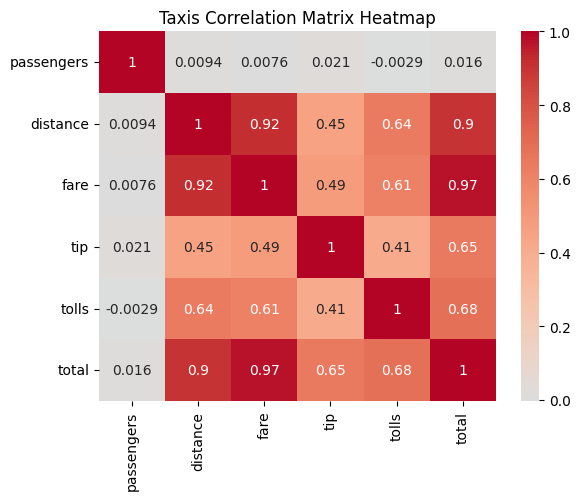

In [14]:
# Section 7 Python cell

LOG.info("---------Visualize Correlation Matrix as a Heatmap---------------")

# Set annotations to True to show correlation values
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",  # try coolwarm, viridis, plasma, or other colormaps
    center=0,
)
plt.title("Taxis Correlation Matrix Heatmap")
plt.show()



Interpretation:

 - Values close to 1 (dark red) = strong positive correlation (both increase together)
 - Values close to -1 (dark blue) = strong negative correlation (one increases, other decreases)
 - Values close to 0 (white) = little or no linear relationship
 - The diagonal is always 1 (each variable correlates perfectly with itself)

From this heatmap, we can see that if a trip had tolls the correlation to the tip was lower than the other factors. Meaning toll trips resulted in lower tips in general.

This is a Markdown cell.

## Section 8. Make Plots

Create simple, notebook-friendly plots.

WHY: Visualizations reveal patterns not obvious in tables.
CUSTOM: Charts will vary depending on the dataset
        and questions of interest.

Common charts include:
1. A scatter plot to see relationships between two variables
2. A box plot to compare distributions across groups

A scatter plot shows the relationship between two numeric variables.
In this example:
- Each dot is one data record shown as x vs y.
- Color (hue) provides a third dimension.

A box plot shows the distribution of one numeric variable across groups.
- The box shows the middle 50% of values.
- The line inside the box is the median.
- The whiskers show the range. Dots beyond the whiskers are outliers.


This is a Markdown cell.

2026-06-05 11:05:54 | INFO | EDA-NB | ---- Creating Scatter Plot to see Relationships ------
2026-06-05 11:05:54 | INFO | EDA-NB | ----   Use clean dataframe ---------------------------
2026-06-05 11:05:54 | INFO | EDA-NB | ----   Set x to distance -----------------------
2026-06-05 11:05:54 | INFO | EDA-NB | ----   Set y to fare --------------------------
2026-06-05 11:05:54 | INFO | EDA-NB | ----   Set the hue (color mapping) to the group column --


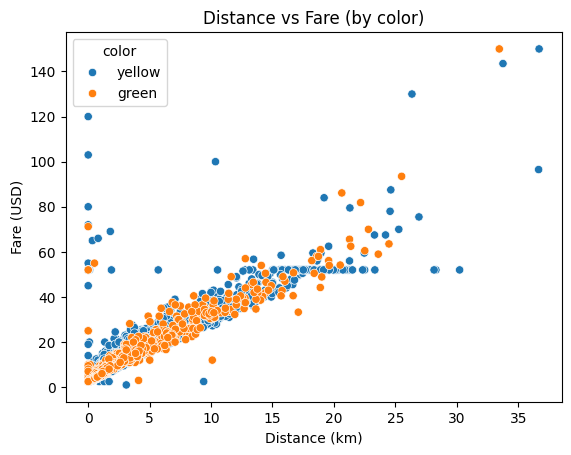

In [15]:
# Section 8 Python cell - use "Run All" so prior cells are executed first.

LOG.info("---- Creating Scatter Plot to see Relationships ------")
LOG.info("----   Use clean dataframe ---------------------------")
LOG.info("----   Set x to distance -----------------------")
LOG.info("----   Set y to fare --------------------------")
LOG.info("----   Set the hue (color mapping) to the group column --")

# Scatter plot to see relationship
scatter_plt: Axes = sns.scatterplot(
        data=df_clean,
        x="distance",
        y="fare",
        hue=GROUP_COL,
    )
scatter_plt.set_xlabel("Distance (km)")
scatter_plt.set_ylabel("Fare (USD)")
scatter_plt.set_title("Distance vs Fare (by color)")

# IN NOTEBOOK: SHOW AS YOU GO
#      plt.show() displays the current chart and closes it
#      Call this before starting a new chart
#      or next chart will be drawn on top of this one
# IN SCRIPT: WAIT TO SHOW TILL THE END
#      Do not call plt.show() here - let figures accumulate
#      so all charts display together with sequential Figure numbers.
#      plt.show() is called once at the end of make_plots()
plt.show()

2026-06-05 11:05:54 | INFO | EDA-NB | ------- Creating another chart -------
2026-06-05 11:05:54 | INFO | EDA-NB | ------ Creating Box Plot to see Distribution: ---------
2026-06-05 11:05:54 | INFO | EDA-NB | ------   Use clean dataframe --------------------------
2026-06-05 11:05:54 | INFO | EDA-NB | ------   Set x to the group column --------------------
2026-06-05 11:05:54 | INFO | EDA-NB | ------   Set y to distance ----------------------


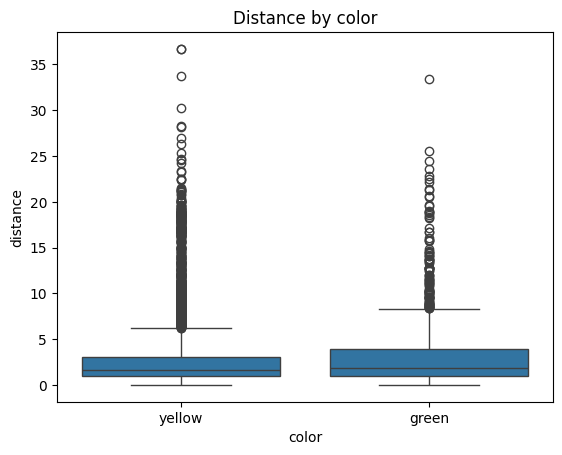

In [16]:
LOG.info("------- Creating another chart -------")
# plt.figure() opens a fresh blank canvas for the next chart
# WHY: Without this, Chart 2 draws on top of Chart 1
plt.figure()

LOG.info("------ Creating Box Plot to see Distribution: ---------")
LOG.info("------   Use clean dataframe --------------------------")
LOG.info("------   Set x to the group column --------------------")
LOG.info("------   Set y to distance ----------------------")

# Box plot to compare distribution across species
box_plt: Axes = sns.boxplot(
        data=df_clean,
        x=GROUP_COL,
        y="distance",
    )
box_plt.set_title("Distance by color")

plt.show()

## Section 9. Summary and Next Steps

At the end, of your notebook, provide:

-  brief summary of your findings 
-  suggested next steps

WHY: EDA is not a final report.
The summary of your data exploration captures you found 
and what you would like to investigate next.

This summary is in code because it is instructional - your summary
will typically be in Markdown as it is good for narrative. 

This is a Markdown cell.


In [17]:
# Section 9 Python cell

LOG.info("========================")
LOG.info("SUMMARY")
LOG.info("========================")
LOG.info(f"Dataset: {DATASET_NAME}")

LOG.info(f"Original rows: {df.shape[0]}")
LOG.info(f"Clean rows:    {df_clean.shape[0]}")

# Get the unique values in the grouping column (e.g. species names)
unique_groups_array: np.ndarray = df_clean[GROUP_COL].unique()

# Sort them alphabetically so the output is consistent and readable
sorted_groups: list[str] = sorted(unique_groups_array)

LOG.info(f"Groups found in {GROUP_COL}: {sorted_groups}")

LOG.info("Strongest correlation: ")
LOG.info("  flipper_length_mm and body_mass_g (~0.87)")

LOG.info("Suggested next step: ")
LOG.info("  Model body_mass_g ~ flipper_length_mm with linear regression")

LOG.info("EDA workflow complete")
LOG.info("IMPORTANT: This script creates chart windows.")
LOG.info("Close any chart windows and terminate this process with CTRL+c as needed.")
LOG.info("========================")
LOG.info("Executed successfully!")
LOG.info("========================")

2026-06-05 11:05:54 | INFO | EDA-NB | ========================
2026-06-05 11:05:54 | INFO | EDA-NB | SUMMARY
2026-06-05 11:05:54 | INFO | EDA-NB | ========================
2026-06-05 11:05:54 | INFO | EDA-NB | Dataset: taxis
2026-06-05 11:05:54 | INFO | EDA-NB | Original rows: 6433
2026-06-05 11:05:54 | INFO | EDA-NB | Clean rows:    6433
2026-06-05 11:05:54 | INFO | EDA-NB | Groups found in color: ['green', 'yellow']
2026-06-05 11:05:54 | INFO | EDA-NB | Strongest correlation: 
2026-06-05 11:05:54 | INFO | EDA-NB |   flipper_length_mm and body_mass_g (~0.87)
2026-06-05 11:05:54 | INFO | EDA-NB | Suggested next step: 
2026-06-05 11:05:54 | INFO | EDA-NB |   Model body_mass_g ~ flipper_length_mm with linear regression
2026-06-05 11:05:54 | INFO | EDA-NB | EDA workflow complete
2026-06-05 11:05:54 | INFO | EDA-NB | IMPORTANT: This script creates chart windows.
2026-06-05 11:05:54 | INFO | EDA-NB | Close any chart windows and terminate this process with CTRL+c as needed.
2026-06-05 11:05:

## Reminder: Run All before sending to GitHub

Before saving a notebook (and running git add-commit-push), click 'Run All' to generate all outputs and display them in the notebook. 

This is a Markdown cell.
